# Prática: Problema do Caixeiro Chinês

## Objetivo
Implementar e testar um algoritmo para a solução ótima do problema do Caixeiro Chinês.

## Estrutura do Trabalho

### 1. Implementação do Algoritmo
- Desenvolver um algoritmo para a solução ótima do problema do Caixeiro Chinês.
- O código deve ser bem comentado, destacando:
  - Implementação do algoritmo de caminho mínimo
  - Implementação do emparelhamento
  - Implementação dos testes

### 2. Testes do Algoritmo
O algoritmo deve ser testado em 5 instâncias:
- **I.** Instância apresentada em aula (para testar a corretude da implementação)
- **II.** 4 instâncias apresentadas no AVA, contendo as distâncias entre pares de cidades

### Observações
- Pode-se utilizar as linguagens: Java, C, C++ ou Python

## Entregas
- Relatório via Moodle contendo:
  - Percurso encontrado em cada instância
  - Explicação da solução para a seleção dos emparelhamentos
- Código fonte comentado via Moodle, destacando as implementações mencionadas acima

## Parte I: Teste com Instância Apresentada em Aula

Nesta seção, será implementado e testado o algoritmo para o problema do Caixeiro Chinês utilizando a biblioteca NetworkX, com uma instância simples para validar a corretude da solução.

In [22]:
# Importa as bibliotecas necessárias para manipulação de grafos, visualização e dados
import networkx as nx  # Biblioteca principal para grafos
import matplotlib.pyplot as plt  # Visualização de grafos
import pandas as pd  # Manipulação de tabelas e dados
import os  # Operações de sistema de arquivos

# Define o diretório de saída para salvar os resultados (imagens, tabelas, etc)
output_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'relatorio', 'resultado'))

# Função principal para resolver o problema do Caixeiro Chinês
# Recebe uma lista de adjacência e retorna o circuito euleriano e o grafo eulerizado
# A lista deve ser no formato: [('A', 'B', 2), ('A', 'C', 3), ...]
def caixeiro_chines(lista_adjacencia):
    """
    Recebe uma lista de adjacência no formato:
    [ ('A', 'B', 2), ('A', 'C', 3), ... ]
    Retorna o circuito euleriano encontrado e o grafo eulerizado.
    """
    G = nx.Graph()  # Cria um grafo simples
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)  # Adiciona arestas com peso
    G_euler = nx.eulerize(G)  # Euleriza o grafo (adiciona arestas duplicadas se necessário)
    circuito = list(nx.eulerian_circuit(G_euler))  # Encontra o circuito euleriano
    return circuito, G_euler

# Função para plotar o grafo simples, mostrando apenas os pesos das arestas
def plotar_grafo(lista_adjacencia, titulo='Grafo', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Recebe uma lista de adjacência e plota o grafo correspondente.
    Parâmetro opcional 'pos' para definir as posições dos vértices.
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    G = nx.Graph()  # Cria o grafo
    for u, v, peso in lista_adjacencia:
        G.add_edge(u, v, weight=peso)  # Adiciona arestas com peso
    if pos is None:
        pos = nx.spring_layout(G, seed=42)  # Gera posições automáticas dos nós
    labels = nx.get_edge_attributes(G, 'weight')  # Obtém os pesos das arestas
    plt.figure(figsize=(8,5))  # Define o tamanho da figura
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_size=12)  # Desenha o grafo
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=13)  # Desenha os pesos das arestas
    plt.title(titulo)  # Título do gráfico
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)  # Garante que o diretório existe
        caminho_fig = os.path.join(output_dir, nome_fig)  # Caminho do arquivo
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)  # Salva a figura
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')  # Mostra o caminho do arquivo
    plt.show()  # Exibe o gráfico

# Função para plotar o circuito euleriano, destacando as arestas do percurso, enumerando e mostrando pesos
def plotar_circuito(G, circuito, titulo='Circuito Euleriano Colorido (Tudo Vermelho)', pos=None, nome_fig=None, mostrar_caminho=False):
    """
    Plota o grafo, destaca o circuito euleriano, enumera as arestas do percurso (inclusive duplicadas),
    coloca a numeração de cada passagem em lados opostos do centro da aresta (ímpar à esquerda, par à direita),
    e exibe os pesos das arestas centralizados.
    Todas as arestas do circuito são desenhadas em vermelho (duplicadas em vermelho escuro e curvadas).
    Se nome_fig for fornecido, salva a figura no diretório de resultados.
    Se mostrar_caminho=True, exibe o caminho do arquivo salvo.
    """
    cor = "red"
    if pos is None:
        pos = nx.spring_layout(G, seed=42)  # Gera posições automáticas
    if not isinstance(G, nx.MultiGraph):
        G = nx.MultiGraph(G)  # Converte para MultiGraph para permitir arestas duplicadas
    edge_total_passagens = {}  # Conta quantas vezes cada aresta aparece no circuito
    for u, v in circuito:
        edge = tuple(sorted([u, v]))
        edge_total_passagens[edge] = edge_total_passagens.get(edge, 0) + 1
    plt.figure(figsize=(10,8))
    ax = plt.gca()
    ax.set_frame_on(False)  # Remove borda do gráfico
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=12)
    edge_passagem = {}  # Conta a passagem atual de cada aresta
    for idx, (u, v) in enumerate(circuito):
        edge = tuple(sorted([u, v]))
        if edge_total_passagens[edge] > 1:
            nx.draw_networkx_edges(
                G, pos, edgelist=[(u, v)], edge_color="red", width=2,
                connectionstyle='arc3,rad=0.3'  # Curvatura
            )
        else:
            nx.draw_networkx_edges(G, pos, edgelist=[(u, v)], edge_color=cor, width=2)
        x = (pos[u][0] + pos[v][0]) / 2  # Posição central da aresta
        y = (pos[u][1] + pos[v][1]) / 2
        if edge_total_passagens[edge] > 1:
            passagem_atual = edge_passagem.get(edge, 0) + 1
            if passagem_atual % 2 == 1:
                deslocamento_x = -0.35  # Ímpar à esquerda
            else:
                deslocamento_x = 0.35  # Par à direita
            deslocamento_y = 0
            plt.text(x + deslocamento_x, y + deslocamento_y, str(idx+1), color='blue', fontsize=8, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        else:
            plt.text(x, y, str(idx+1), color='blue', fontsize=8, fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.5))
        edge_passagem[edge] = edge_passagem.get(edge, 0) + 1
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=13)
    plt.title(titulo)
    if nome_fig is not None:
        os.makedirs(output_dir, exist_ok=True)
        caminho_fig = os.path.join(output_dir, nome_fig)
        plt.savefig(caminho_fig, bbox_inches='tight', dpi=150)
        if mostrar_caminho:
            print(f'Arquivo salvo em: {caminho_fig}')
    plt.show()

# Função para mostrar o percurso do circuito euleriano no console, marcando emparelhamento
def mostrar_percurso(circuito, G_euler, nome_csv):
    edge_count = {}
    for u, v in circuito:
        edge = tuple(sorted([u, v]))
        edge_count[edge] = edge_count.get(edge, 0) + 1
    print("Origem | Destino | Peso | Emparelhado")
    for idx, (u, v) in enumerate(circuito):
        dados_arestas = G_euler.get_edge_data(u, v)
        if isinstance(dados_arestas, dict):
            if 0 in dados_arestas:
                peso = dados_arestas[0].get('weight', '-')
            else:
                peso = list(dados_arestas.values())[0].get('weight', '-')
        else:
            peso = '-'
        emparelhado = 'Sim' if edge_count[tuple(sorted([u, v]))] > 1 else 'Não'
        print(f"{idx+1:>3} | {u:>6} | {v:>7} | {peso:>4} | {emparelhado}")
    
    tabela_percurso(circuito, G_euler, nome_csv=nome_csv)

# Função para gerar e salvar a tabela do percurso do circuito euleriano com coluna emparelhado
def tabela_percurso(circuito, G_euler, nome_csv='percurso_emparelhado.csv', mostrar_caminho=False):
    dados = []
    edge_count = {}
    for u, v in circuito:
        edge = tuple(sorted([u, v]))
        edge_count[edge] = edge_count.get(edge, 0) + 1
    for idx, (u, v) in enumerate(circuito):
        peso = '-'
        emparelhado = 'Sim' if edge_count[tuple(sorted([u, v]))] > 1 else 'Não'
        if isinstance(G_euler, nx.MultiGraph):
            edge_data = G_euler.get_edge_data(u, v)
            if edge_data:
                for k in edge_data:
                    if 'weight' in edge_data[k]:
                        peso = edge_data[k]['weight']
                        break
        else:
            if G_euler.has_edge(u, v):
                peso = G_euler[u][v].get('weight', '-')
        dados.append({'Origem': u, 'Destino': v, 'Peso': peso, 'Emparelhado': emparelhado})
    df = pd.DataFrame(dados)
    print(df)
    os.makedirs(output_dir, exist_ok=True)
    caminho_csv = os.path.join(output_dir, nome_csv)
    df.to_csv(caminho_csv, index=False, encoding='utf-8')
    if mostrar_caminho:
        print(f'Arquivo salvo em: {caminho_csv}')


## Parte II: Teste com Instância Apresentada em Aula

A segunda parte do trabalho consiste no teste do algoritmo implementadoem5 instâncias:

### I - Instância apresentada em aula a fim de testar a corretude da implementação:


--- Processando Instância: aula.tsp ---
> Dimensão lida (Vértices): 7
> Arestas originais: 10


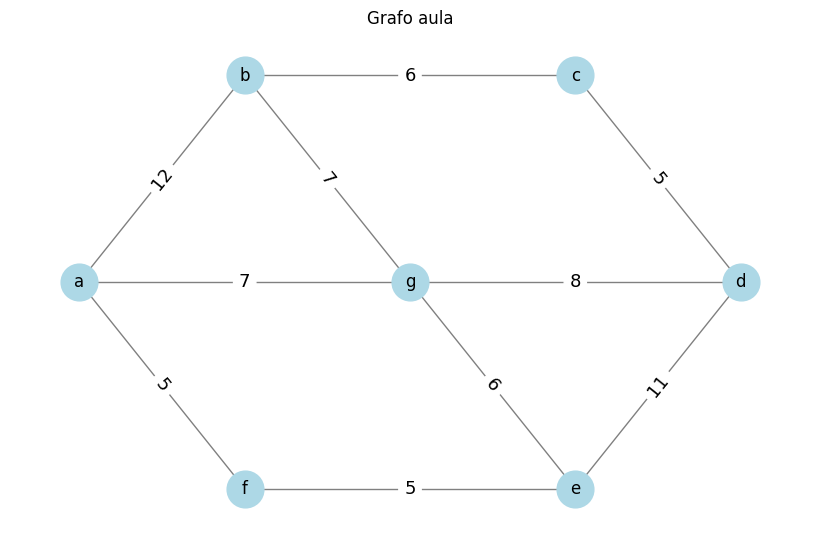

> Resultado Final:
  - Custo Mínimo Total: 95
  - Tamanho do Circuito (nº passos): 12
Origem | Destino | Peso | Emparelhado
  1 |      a |       f |    5 | Não
  2 |      f |       e |    5 | Não
  3 |      e |       d |   11 | Sim
  4 |      d |       e |   11 | Sim
  5 |      e |       g |    6 | Não
  6 |      g |       d |    8 | Não
  7 |      d |       c |    5 | Não
  8 |      c |       b |    6 | Não
  9 |      b |       g |    7 | Não
 10 |      g |       a |    7 | Não
 11 |      a |       b |   12 | Sim
 12 |      b |       a |   12 | Sim
   Origem Destino  Peso Emparelhado
0       a       f     5         Não
1       f       e     5         Não
2       e       d    11         Sim
3       d       e    11         Sim
4       e       g     6         Não
5       g       d     8         Não
6       d       c     5         Não
7       c       b     6         Não
8       b       g     7         Não
9       g       a     7         Não
10      a       b    12         Sim
11      b   

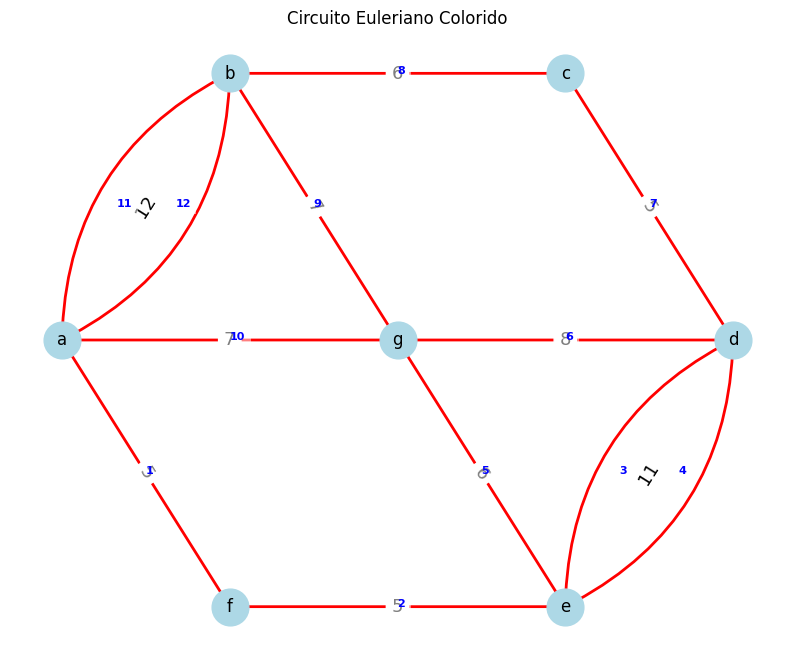

In [23]:
# Exemplo de uso
lista = [
    ('a', 'b', 12),
    ('a', 'g', 7),
    ('a', 'f', 5),
    ('b', 'c', 6),
    ('b', 'g', 7),
    ('c', 'd', 5),
    ('d', 'g', 8),
    ('d', 'e', 11),
    ('e', 'f', 5),
    ('e', 'g', 6),
]

# Coleta dados da instância de teste
dimensao_teste = len(set([u for u, v, w in lista] + [v for u, v, w in lista]))
num_arestas_teste = len(lista)

print(f'\n--- Processando Instância: aula.tsp ---')
print(f'> Dimensão lida (Vértices): {dimensao_teste}')
print(f'> Arestas originais: {num_arestas_teste}')

pos = { 'a': (0,0), 
        'b': (2,2), 
        'c': (6,2), 
        'd': (8,0),
        'e': (6,-2),
        'f': (2,-2),
        'g': (4,0),
        }
plotar_grafo(lista, titulo='Grafo aula', pos=pos, nome_fig='grafo_aula.png')
circuito, G_euler = caixeiro_chines(lista)

# Calcula custo total do circuito de teste
custo_total_teste = 0
for u, v in circuito:
    if isinstance(G_euler, nx.MultiGraph):
        edge_data = G_euler.get_edge_data(u, v)
        if edge_data:
            for k in edge_data:
                if 'weight' in edge_data[k]:
                    custo_total_teste += edge_data[k]['weight']
                    break
    else:
        if G_euler.has_edge(u, v):
            custo_total_teste += G_euler[u][v].get('weight', 0)

tamanho_circuito_teste = len(circuito)

print(f'> Resultado Final:')
print(f'  - Custo Mínimo Total: {custo_total_teste}')
print(f'  - Tamanho do Circuito (nº passos): {tamanho_circuito_teste}')

mostrar_percurso(circuito, G_euler, nome_csv='percurso_aula.csv')
# Plota o circuito enumerando as arestas, sem sobrescrever os pesos
plotar_circuito(G_euler, circuito, titulo='Circuito Euleriano Colorido', pos=pos, nome_fig='circuito_euleriano_aula.png')


### II.04 instâncias apresentadas no AVA contendo as distâncias entre pares de cidades;


--- Processando Instância: aula.tsp ---
> Dimensão lida (Vértices): 7
> Arestas originais: 10
> Resultado Final:
  - Custo Mínimo Total: 95
  - Tamanho do Circuito (nº passos): 12
  - Vértices de grau ímpar: 4
  - Arestas duplicadas: 2
  - Overhead: 23 (31.94%)
  - Taxa de duplicação: 20.00%

--- Processando Instância: gr15.tsp ---
> Dimensão lida (Vértices): 15
> Arestas originais: 40
> Resultado Final:
  - Custo Mínimo Total: 2105
  - Tamanho do Circuito (nº passos): 44
  - Vértices de grau ímpar: 8
  - Arestas duplicadas: 4
  - Overhead: 234 (12.51%)
  - Taxa de duplicação: 10.00%
Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\grafo_gr15.tsp.png


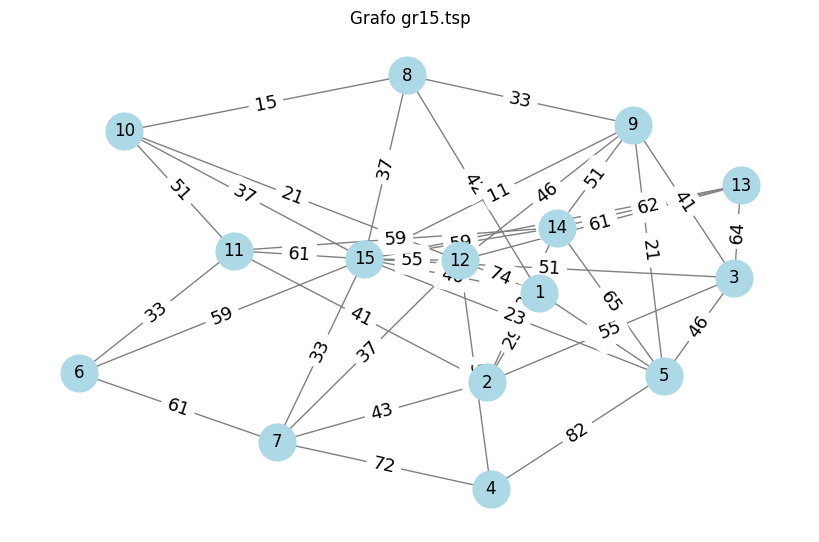

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr15.tsp.png


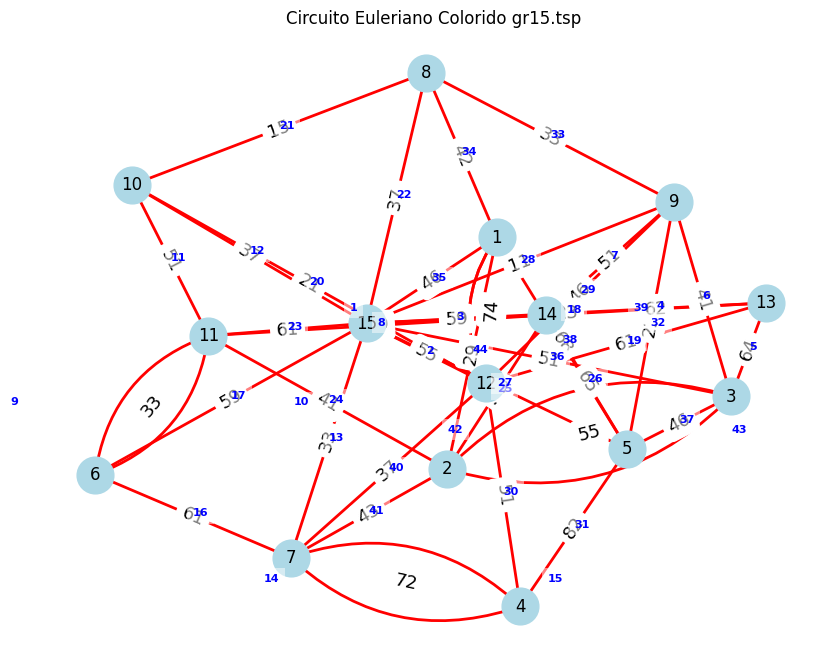

Origem | Destino | Peso | Emparelhado
  1 |      1 |      12 |   74 | Sim
  2 |     12 |      15 |   55 | Não
  3 |     15 |      14 |   59 | Não
  4 |     14 |      13 |   62 | Não
  5 |     13 |       3 |   64 | Não
  6 |      3 |       9 |   41 | Não
  7 |      9 |      14 |   51 | Não
  8 |     14 |      11 |   59 | Não
  9 |     11 |       6 |   33 | Sim
 10 |      6 |      11 |   33 | Sim
 11 |     11 |      10 |   51 | Não
 12 |     10 |      15 |   37 | Não
 13 |     15 |       7 |   33 | Não
 14 |      7 |       4 |   72 | Sim
 15 |      4 |       7 |   72 | Sim
 16 |      7 |       6 |   61 | Não
 17 |      6 |      15 |   59 | Não
 18 |     15 |      13 |   23 | Não
 19 |     13 |      12 |   61 | Não
 20 |     12 |      10 |   21 | Não
 21 |     10 |       8 |   15 | Não
 22 |      8 |      15 |   37 | Não
 23 |     15 |      11 |   61 | Não
 24 |     11 |       2 |   41 | Não
 25 |      2 |      14 |   52 | Não
 26 |     14 |       5 |   65 | Não
 27 |      5 |      15 |  

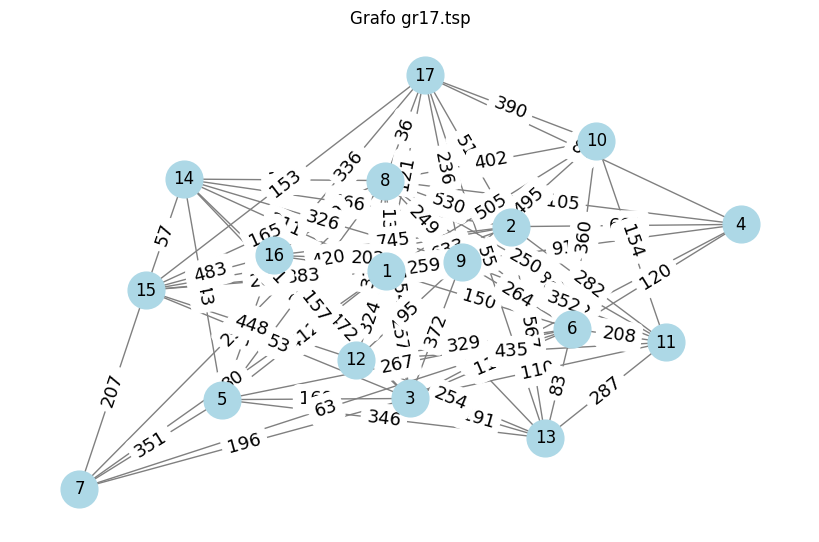

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr17.tsp.png


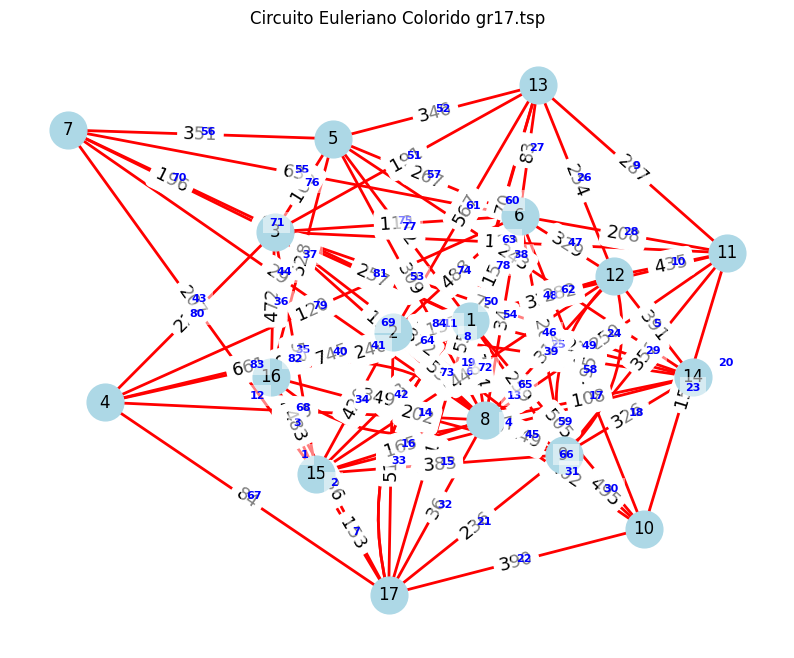

Origem | Destino | Peso | Emparelhado
  1 |      1 |      17 |  121 | Sim
  2 |     17 |      16 |  336 | Não
  3 |     16 |      15 |  483 | Não
  4 |     15 |      14 |   57 | Não
  5 |     14 |      12 |  391 | Não
  6 |     12 |      15 |  448 | Não
  7 |     15 |      17 |  153 | Não
  8 |     17 |      13 |   55 | Não
  9 |     13 |      11 |  287 | Não
 10 |     11 |      12 |  435 | Não
 11 |     12 |      16 |  157 | Não
 12 |     16 |       8 |  349 | Sim
 13 |      8 |      16 |  349 | Sim
 14 |     16 |       9 |  202 | Não
 15 |      9 |      15 |  383 | Não
 16 |     15 |       8 |  165 | Não
 17 |      8 |      14 |  108 | Não
 18 |     14 |       9 |  326 | Não
 19 |      9 |      12 |   95 | Sim
 20 |     12 |       9 |   95 | Sim
 21 |      9 |      17 |  236 | Não
 22 |     17 |      10 |  390 | Não
 23 |     10 |      11 |  154 | Não
 24 |     11 |       8 |  250 | Não
 25 |      8 |      12 |  314 | Não
 26 |     12 |      13 |  254 | Não
 27 |     13 |       6 |  

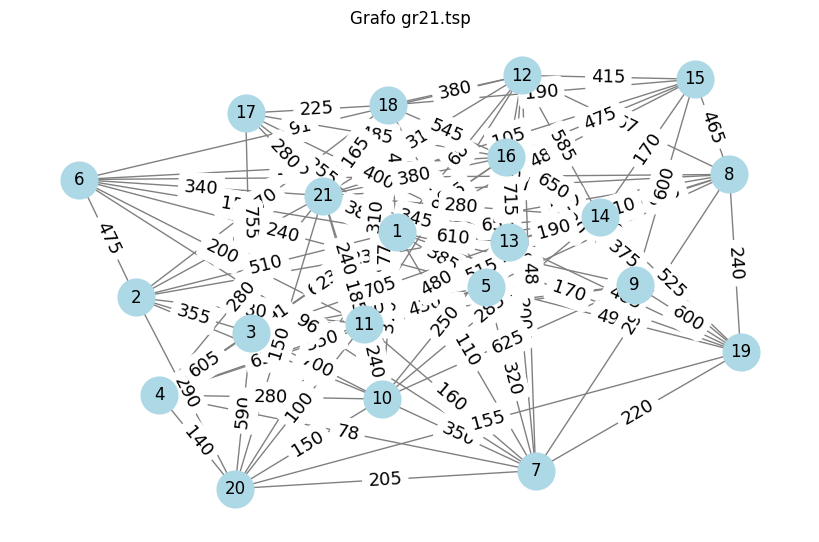

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr21.tsp.png


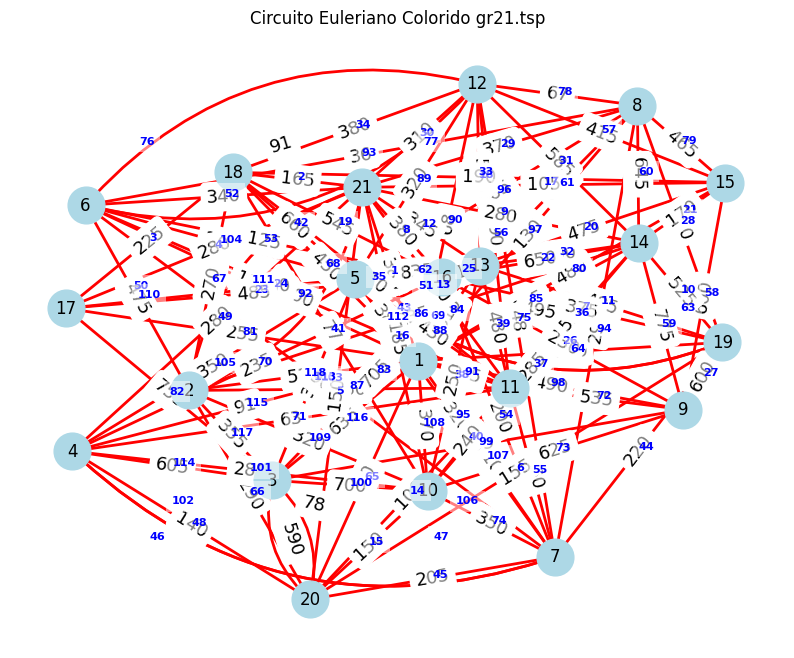

Origem | Destino | Peso | Emparelhado
  1 |      1 |      21 |  380 | Não
  2 |     21 |      18 |  165 | Não
  3 |     18 |      17 |  225 | Não
  4 |     17 |      21 |  280 | Não
  5 |     21 |      20 |  150 | Não
  6 |     20 |      19 |  155 | Não
  7 |     19 |      16 |  375 | Não
  8 |     16 |      21 |  380 | Não
  9 |     21 |      14 |  280 | Não
 10 |     14 |      19 |  525 | Não
 11 |     19 |      13 |  485 | Não
 12 |     13 |      21 |  345 | Não
 13 |     21 |      11 |  240 | Não
 14 |     11 |      20 |  100 | Não
 15 |     20 |      10 |  150 | Não
 16 |     10 |      21 |  185 | Não
 17 |     21 |      15 |  105 | Não
 18 |     15 |      18 |  190 | Não
 19 |     18 |      16 |  545 | Não
 20 |     16 |      15 |  475 | Não
 21 |     15 |      14 |  170 | Não
 22 |     14 |      16 |  650 | Não
 23 |     16 |      17 |  485 | Não
 24 |     17 |      13 |  400 | Não
 25 |     13 |      16 |  715 | Não
 26 |     16 |       9 |  230 | Não
 27 |      9 |      19 |  

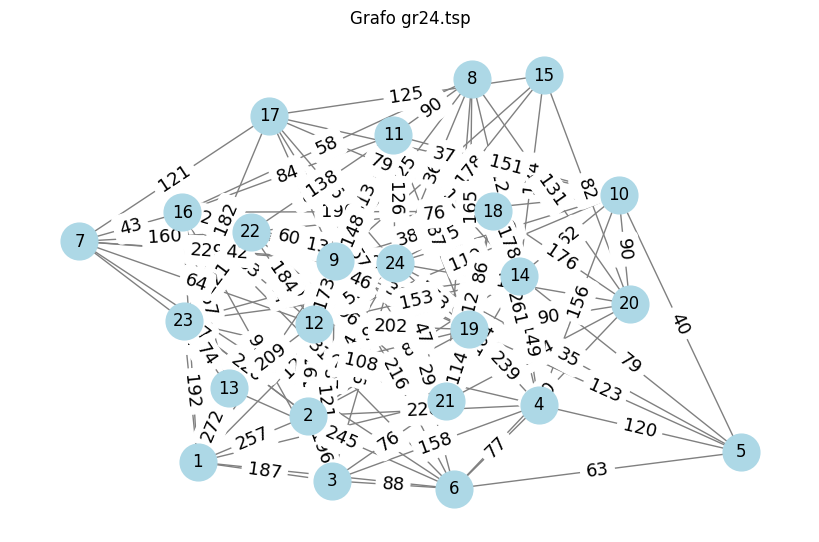

Arquivo salvo em: d:\GitHub\DoutoradoCefet\TeoriaGrafos\praticas\pratica02\relatorio\resultado\circuito_euleriano_gr24.tsp.png


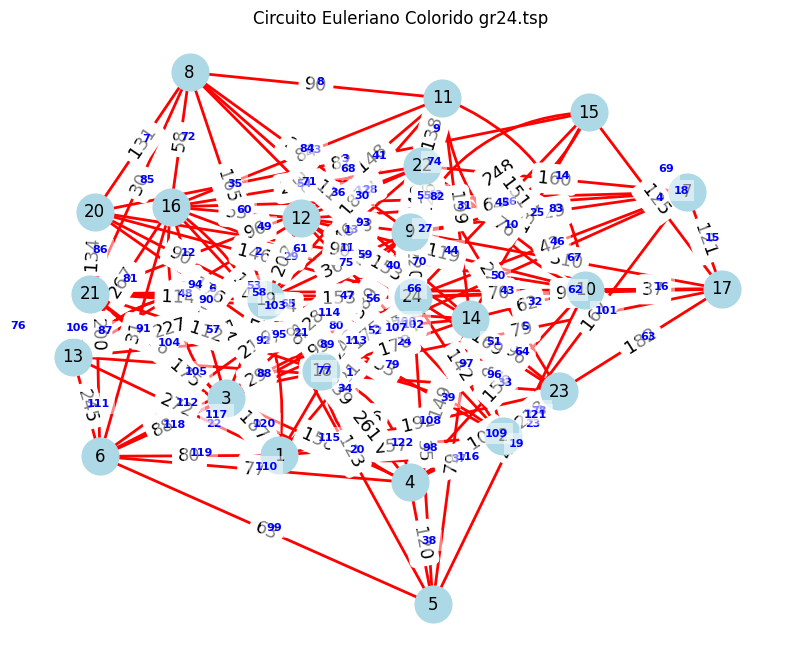

Origem | Destino | Peso | Emparelhado
  1 |      1 |      24 |  121 | Não
  2 |     24 |      20 |  146 | Não
  3 |     20 |      15 |   82 | Não
  4 |     15 |      17 |  125 | Não
  5 |     17 |      18 |   79 | Não
  6 |     18 |      20 |  176 | Não
  7 |     20 |       8 |  131 | Não
  8 |      8 |      11 |   90 | Não
  9 |     11 |      22 |  138 | Não
 10 |     22 |      10 |   76 | Não
 11 |     10 |      20 |   90 | Não
 12 |     20 |      19 |   90 | Não
 13 |     19 |      22 |   46 | Não
 14 |     22 |       7 |  160 | Não
 15 |      7 |      17 |  121 | Não
 16 |     17 |      10 |   37 | Não
 17 |     10 |      11 |  151 | Sim
 18 |     11 |      10 |  151 | Sim
 19 |     10 |       5 |   40 | Não
 20 |      5 |      19 |  123 | Não
 21 |     19 |      18 |   86 | Não
 22 |     18 |       4 |  261 | Sim
 23 |      4 |      18 |  261 | Sim
 24 |     18 |      14 |  178 | Não
 25 |     14 |      15 |  134 | Não
 26 |     15 |      24 |  178 | Não
 27 |     24 |      22 |  

In [24]:
import re

def ler_tsp_lower_diag_row(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    # Encontrar a linha EDGE_WEIGHT_SECTION
    start = None
    for i, line in enumerate(lines):
        if 'EDGE_WEIGHT_SECTION' in line:
            start = i + 1
            break
    if start is None:
        raise ValueError('EDGE_WEIGHT_SECTION não encontrada')
    # Extrair dimensão
    dim = None
    for line in lines:
        m = re.match(r'DIMENSION\s*:\s*(\d+)', line)
        if m:
            dim = int(m.group(1))
            break
    if dim is None:
        raise ValueError('DIMENSION não encontrada')
    # Ler matriz triangular inferior
    matriz = [[0]*dim for _ in range(dim)]
    idx = 0
    for i in range(dim):
        vals = []
        while len(vals) < i+1:
            vals += [int(x) for x in lines[start+idx].strip().split()]
            idx += 1
        for j in range(i+1):
            matriz[i][j] = vals[j]
            matriz[j][i] = vals[j]
    return matriz
def gerar_pos(lista):
    G_tmp = nx.Graph()
    for u, v, peso in lista:
        G_tmp.add_edge(u, v, weight=peso)
    pos = nx.spring_layout(G_tmp, seed=42)
    return pos

def matriz_para_lista_adjacencia(matriz):
    dim = len(matriz)
    lista = []
    for i in range(dim):
        for j in range(i+1, dim):
            if matriz[i][j] > 0:
                lista.append((str(i+1), str(j+1), matriz[i][j]))
    return lista

def calcular_metricas(G, G_euler, lista_original, circuito):
    """Calcula métricas detalhadas do algoritmo"""
    metricas = {}
    
    # 1. Custo original
    custo_original = sum([peso for _, _, peso in lista_original])
    metricas['custo_original'] = custo_original
    
    # 2. Vértices de grau ímpar no grafo original
    vertices_grau_impar = [node for node, degree in G.degree() if degree % 2 == 1]
    metricas['num_vertices_grau_impar'] = len(vertices_grau_impar)
    
    # 3. Custo total do circuito
    custo_total = 0
    for u, v in circuito:
        if isinstance(G_euler, nx.MultiGraph):
            edge_data = G_euler.get_edge_data(u, v)
            if edge_data:
                for k in edge_data:
                    if 'weight' in edge_data[k]:
                        custo_total += edge_data[k]['weight']
                        break
        else:
            if G_euler.has_edge(u, v):
                custo_total += G_euler[u][v].get('weight', 0)
    metricas['custo_final'] = custo_total
    
    # 4. Overhead do emparelhamento
    overhead = custo_total - custo_original
    metricas['overhead_emparelhamento'] = overhead
    metricas['overhead_percentual'] = (overhead / custo_original * 100) if custo_original > 0 else 0
    
    # 5. Arestas duplicadas
    arestas_duplicadas = overhead // (sum([peso for _, _, peso in lista_original]) / len(lista_original)) if len(lista_original) > 0 else 0
    # Forma mais correta: contar arestas que aparecem múltiplas vezes no circuito
    edge_count = {}
    for u, v in circuito:
        edge = tuple(sorted([u, v]))
        edge_count[edge] = edge_count.get(edge, 0) + 1
    num_arestas_duplicadas = sum([1 for count in edge_count.values() if count > 1])
    soma_duplicacoes = sum([count - 1 for count in edge_count.values() if count > 1])
    metricas['num_arestas_duplicadas'] = num_arestas_duplicadas
    metricas['soma_duplicacoes'] = soma_duplicacoes
    
    # 6. Taxa de duplicação
    metricas['taxa_duplicacao'] = (soma_duplicacoes / len(lista_original) * 100) if len(lista_original) > 0 else 0
    
    # 7. Grau mínimo, máximo e médio
    graus = [degree for node, degree in G_euler.degree()]
    metricas['grau_minimo'] = min(graus) if graus else 0
    metricas['grau_maximo'] = max(graus) if graus else 0
    metricas['grau_medio'] = sum(graus) / len(graus) if graus else 0
    
    # 8. Número de componentes conexas
    metricas['num_componentes'] = nx.number_connected_components(G_euler)
    
    return metricas

# Cria lista para armazenar todos os resultados (incluindo o teste)
resultados = []
analises_detalhadas = []

# Adiciona resultado do teste
print(f'\n--- Processando Instância: aula.tsp ---')
print(f'> Dimensão lida (Vértices): {dimensao_teste}')
print(f'> Arestas originais: {num_arestas_teste}')

# Cria grafo original para análise
G_teste = nx.Graph()
for u, v, peso in lista:
    G_teste.add_edge(u, v, weight=peso)

metricas_teste = calcular_metricas(G_teste, G_euler, lista, circuito)

print(f'> Resultado Final:')
print(f'  - Custo Mínimo Total: {custo_total_teste}')
print(f'  - Tamanho do Circuito (nº passos): {tamanho_circuito_teste}')
print(f'  - Vértices de grau ímpar: {metricas_teste["num_vertices_grau_impar"]}')
print(f'  - Arestas duplicadas: {metricas_teste["num_arestas_duplicadas"]}')
print(f'  - Overhead: {metricas_teste["overhead_emparelhamento"]} ({metricas_teste["overhead_percentual"]:.2f}%)')
print(f'  - Taxa de duplicação: {metricas_teste["taxa_duplicacao"]:.2f}%')

resultados.append({
    'Instância': 'aula.tsp',
    'Dimensão (Vértices)': dimensao_teste,
    'Arestas Originais': num_arestas_teste,
    'Custo Mínimo Total': custo_total_teste,
    'Tamanho do Circuito': tamanho_circuito_teste
})

analises_detalhadas.append({
    'Instância': 'aula.tsp',
    'Custo Original': metricas_teste['custo_original'],
    'Custo Final': metricas_teste['custo_final'],
    'Vértices Grau Ímpar': metricas_teste['num_vertices_grau_impar'],
    'Arestas Duplicadas': metricas_teste['num_arestas_duplicadas'],
    'Overhead': metricas_teste['overhead_emparelhamento'],
    'Overhead (%)': f"{metricas_teste['overhead_percentual']:.2f}",
    'Taxa Duplicação (%)': f"{metricas_teste['taxa_duplicacao']:.2f}",
    'Grau Mínimo': metricas_teste['grau_minimo'],
    'Grau Máximo': metricas_teste['grau_maximo'],
    'Grau Médio': f"{metricas_teste['grau_medio']:.2f}",
    'Componentes Conexas': metricas_teste['num_componentes']
})

# Caminhos dos arquivos
arquivos = ['gr15.tsp', 'gr17.tsp', 'gr21.tsp', 'gr24.tsp']

for arquivo in arquivos:
    matriz = ler_tsp_lower_diag_row(f'../{arquivo}')
    lista = matriz_para_lista_adjacencia(matriz)
    
    dimensao = len(matriz)
    num_arestas_originais = len(lista)
    
    print(f'\n--- Processando Instância: {arquivo} ---')
    print(f'> Dimensão lida (Vértices): {dimensao}')
    print(f'> Arestas originais: {num_arestas_originais}')
    
    pos = gerar_pos(lista)
    
    # Cria grafo original para análise
    G = nx.Graph()
    for u, v, peso in lista:
        G.add_edge(u, v, weight=peso)
    
    circuito, G_euler = caixeiro_chines(lista)
    
    # Calcula custo total do circuito
    custo_total = 0
    for u, v in circuito:
        if isinstance(G_euler, nx.MultiGraph):
            edge_data = G_euler.get_edge_data(u, v)
            if edge_data:
                for k in edge_data:
                    if 'weight' in edge_data[k]:
                        custo_total += edge_data[k]['weight']
                        break
        else:
            if G_euler.has_edge(u, v):
                custo_total += G_euler[u][v].get('weight', 0)
    
    tamanho_circuito = len(circuito)
    
    # Calcula métricas detalhadas
    metricas = calcular_metricas(G, G_euler, lista, circuito)
    
    print(f'> Resultado Final:')
    print(f'  - Custo Mínimo Total: {custo_total}')
    print(f'  - Tamanho do Circuito (nº passos): {tamanho_circuito}')
    print(f'  - Vértices de grau ímpar: {metricas["num_vertices_grau_impar"]}')
    print(f'  - Arestas duplicadas: {metricas["num_arestas_duplicadas"]}')
    print(f'  - Overhead: {metricas["overhead_emparelhamento"]} ({metricas["overhead_percentual"]:.2f}%)')
    print(f'  - Taxa de duplicação: {metricas["taxa_duplicacao"]:.2f}%')
    
    # Armazena resultados
    resultados.append({
        'Instância': arquivo,
        'Dimensão (Vértices)': dimensao,
        'Arestas Originais': num_arestas_originais,
        'Custo Mínimo Total': custo_total,
        'Tamanho do Circuito': tamanho_circuito
    })
    
    analises_detalhadas.append({
        'Instância': arquivo,
        'Custo Original': metricas['custo_original'],
        'Custo Final': metricas['custo_final'],
        'Vértices Grau Ímpar': metricas['num_vertices_grau_impar'],
        'Arestas Duplicadas': metricas['num_arestas_duplicadas'],
        'Overhead': metricas['overhead_emparelhamento'],
        'Overhead (%)': f"{metricas['overhead_percentual']:.2f}",
        'Taxa Duplicação (%)': f"{metricas['taxa_duplicacao']:.2f}",
        'Grau Mínimo': metricas['grau_minimo'],
        'Grau Máximo': metricas['grau_maximo'],
        'Grau Médio': f"{metricas['grau_medio']:.2f}",
        'Componentes Conexas': metricas['num_componentes']
    })
    
    plotar_grafo(lista, titulo=f'Grafo {arquivo}', nome_fig=f'grafo_{arquivo}.png', mostrar_caminho=True, pos=pos)
    plotar_circuito(G_euler, circuito, titulo=f'Circuito Euleriano Colorido {arquivo}', nome_fig=f'circuito_euleriano_{arquivo}.png', mostrar_caminho=True)
    mostrar_percurso(circuito, G_euler, nome_csv=f'percurso_{arquivo}.csv')

# Salva arquivo único mesclado em CSV
df_resultados = pd.DataFrame(resultados)
df_analises = pd.DataFrame(analises_detalhadas)
os.makedirs(output_dir, exist_ok=True)

# Mescla resumo e análises em um único DataFrame
df_mesclado = df_resultados.merge(df_analises, on='Instância', how='inner')

caminho_csv_final = os.path.join(output_dir, 'resultados.csv')
df_mesclado.to_csv(caminho_csv_final, index=False, encoding='utf-8')
print(f'\n--- RESULTADOS FINAIS (MESCLADOS) ---')
print(df_mesclado)
print(f'\nResultados salvos em: {caminho_csv_final}')